## 4.0 Contexto del notebook

Este notebook continúa directamente el trabajo realizado en el **Notebook 3**, donde se entrenó un modelo base y se generaron señales probabilísticas.

Aquí **no se entrena ningún modelo nuevo**.  
Se reutilizan los siguientes artefactos:

- `y_test`, `y_pred`  
- `y_proba`  
- scores internos del modelo

El objetivo es **analizar métricas de evaluación** y entender correctamente su significado.

En particular:
- qué información aportan métricas como accuracy,
- qué información esconden,
- y por qué una buena métrica **no implica** una buena decisión.

📌 Este notebook trata sobre **lectura crítica de métricas**, no sobre mejora del modelo ni toma de decisiones.

---
---
---

### Carga de artefactos del modelo

Este notebook **no entrena modelos**.  
Carga los artefactos generados en el Notebook 3 para analizarlos desde el punto de vista de métricas.

Los objetos cargados representan:
- resultados finales del modelo,
- señales ya producidas,
- datos inmutables para el análisis.

In [7]:
import numpy as np

# Carga de artefactos persistidos en el Notebook 3
y_test = np.load("../artifacts/y_test.npy")
y_pred = np.load("../artifacts/y_pred.npy")
y_proba = np.load("../artifacts/y_proba.npy")
scores = np.load("../artifacts/scores.npy")

y_test.shape, y_pred.shape, y_proba.shape, scores.shape

((975,), (975,), (975, 7), (975, 7))

## 4.1 Accuracy: la métrica más usada… y más mal interpretada

El **accuracy** mide la proporción de casos en los que el modelo acierta exactamente la clase.

Aquí lo usamos como:
- una **señal inicial** de desempeño,
- útil para contexto y reporting,
- pero insuficiente para decidir.

Limitación clave:
- no distingue entre tipos de error,
- no refleja incertidumbre,
- no incorpora costo ni riesgo.

📌 Accuracy informa. No gobierna.

In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.5517948717948717

Lectura de resultados:

- Los artefactos cargados son **consistentes**:
  - 975 observaciones en test.
  - 7 clases posibles de `calidad`.
- El **accuracy ≈ 0.55** indica que el modelo acierta exactamente la clase en poco más de la mitad de los casos.

Este valor confirma que:
- el modelo **no es trivial** (muy por encima del azar),
- pero tampoco es lo suficientemente preciso como para sostener decisiones directas.

📌 El accuracy sirve aquí como **referencia descriptiva**, no como criterio de acción.

---
---
---

## 4.2 Matriz de confusión: ver el error, no esconderlo

* Construcción de la matriz de confusión.
* Lectura correcta:

  * diagonal
  * errores entre clases vecinas
* Diferencia entre:

  * error “técnico”
  * error “operativo”.

**Visualizaciones:**

* Matriz de confusión estándar.
* Matriz normalizada por fila.

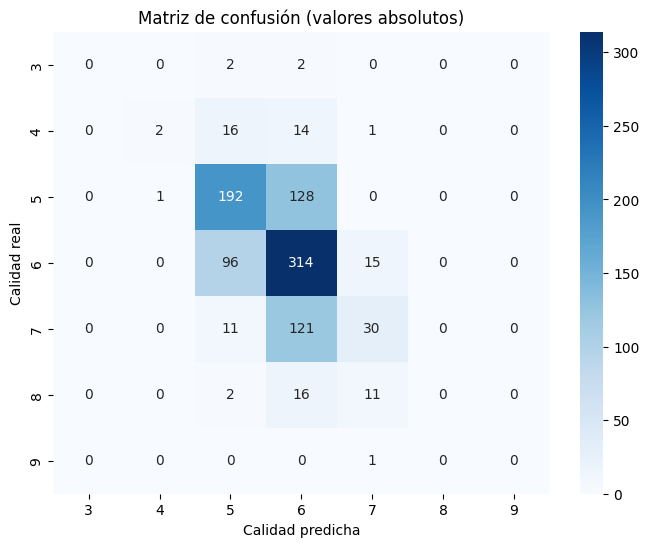

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Clases reales de calidad (en el orden del modelo)
labels = [3, 4, 5, 6, 7, 8, 9]

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Matriz de confusión (valores absolutos)")
plt.xlabel("Calidad predicha")
plt.ylabel("Calidad real")
plt.show()

> Esta imagen muestra cómo el modelo compara la **calidad real del vino** (eje vertical) con la **calidad que el modelo predice** (eje horizontal).
>
> Los números sobre la diagonal indican los aciertos: cuando el modelo predijo exactamente la misma calidad que la real. Por ejemplo, se observa que muchos vinos con calidad **6** fueron correctamente identificados como **6**, lo que explica el bloque más oscuro en el centro.
>
> Fuera de la diagonal aparecen los errores. La mayoría de ellos ocurren entre valores cercanos, como confundir un **5 con un 6** o un **6 con un 7**. Esto es bastante natural, ya que incluso para una persona distinguir entre calidades muy parecidas no siempre es sencillo.
>
> Casi no se ven errores extremos, como decir que un vino de calidad baja es de calidad muy alta, o viceversa. Esto indica que el modelo no “se desorienta”, sino que se equivoca de forma moderada.
>
> En conjunto, la imagen muestra que el modelo entiende el orden general de las calidades y que, cuando falla, suele hacerlo por poco. Esto no significa que ya podamos tomar decisiones automáticas con él, pero sí que sus errores son coherentes y fáciles de interpretar.

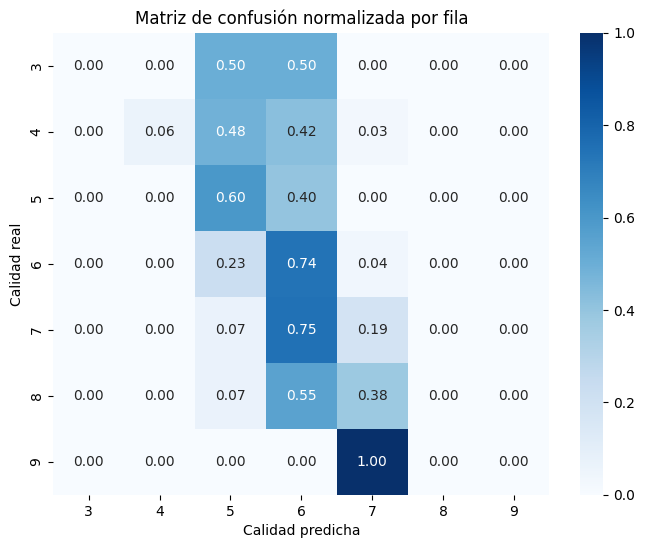

In [11]:
# Etiquetas reales de calidad (en el orden del modelo)
labels = [3, 4, 5, 6, 7, 8, 9]

# Matriz de confusión normalizada por fila (clase real)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Matriz de confusión normalizada por fila")
plt.xlabel("Calidad predicha")
plt.ylabel("Calidad real")
plt.show()

### Lectura de la matriz de confusión normalizada

Esta matriz muestra **cómo se distribuyen las predicciones del modelo para cada calidad real de vino**, expresadas como proporciones.

Cada fila representa una **calidad real**, y cada fila suma 1 (o 100%).  
Esto permite responder a la pregunta:

> “Cuando un vino tiene esta calidad real, ¿qué tan seguido el modelo lo clasifica en cada categoría?”

La diagonal principal indica los **aciertos**:  
valores altos significan que el modelo suele acertar esa calidad.

Los valores fuera de la diagonal muestran **confusiones**.  
En este caso, la mayoría de los errores ocurren entre **calidades vecinas** (por ejemplo, 5 ↔ 6 o 6 ↔ 7), lo cual es esperable en un problema donde la calidad es gradual y subjetiva.

Se observa que:
- El modelo clasifica bien las calidades centrales (5 y 6).
- Existe una tendencia a “empujar” calidades altas y bajas hacia valores intermedios, especialmente hacia la calidad 6.
- Las calidades poco frecuentes (como 3 o 9) están peor representadas, lo que refleja limitaciones del dato más que del modelo.

En conjunto, esta matriz no indica si el modelo debe usarse para tomar decisiones,  
pero sí permite **entender cómo se equivoca** y **dónde concentra su incertidumbre**.

📌 Medir errores es el paso previo a decidir qué errores son aceptables.

---

### Conclusión conjunta: qué nos dicen realmente estas dos matrices

Vistas en conjunto, las dos matrices cuentan la **misma historia desde dos ángulos distintos**.

La matriz de confusión en **valores absolutos** muestra **dónde está el volumen**:
- el modelo acierta principalmente en las calidades más frecuentes (5 y 6),
- los errores se concentran también en esas zonas,
- las calidades extremas aparecen poco, tanto en aciertos como en errores.

La matriz **normalizada por fila** muestra **el comportamiento relativo del modelo**:
- cuando se equivoca, casi siempre lo hace entre **calidades vecinas**,
- no hay saltos bruscos (por ejemplo, de 3 a 9),
- el modelo tiende a “regresar” las predicciones hacia valores intermedios.

La lectura combinada es clara:
- el modelo **no es arbitrario**,
- entiende la estructura ordinal del problema,
- pero también refleja la ambigüedad natural del concepto de “calidad”.

Al mismo tiempo, estas gráficas dejan algo muy importante en evidencia:
- no todos los errores son iguales,
- y **las métricas globales no cuentan esta historia**.

📌 Estas matrices no indican qué decisión tomar.  
📌 Indican **qué tipo de errores existen**, para que en los siguientes pasos se pueda decidir **cuáles importan y cuáles no**.

---
---
---

## 4.3 No todos los errores pesan igual

Hasta ahora hemos visto **cuántos errores hay** y **cómo se distribuyen**.  
El siguiente paso es entender algo más importante:

> **No todos los errores tienen el mismo impacto.**

Dos modelos con el mismo accuracy pueden comportarse de forma muy distinta cuando se usan en la práctica.

En esta sección buscamos:
- identificar **qué tipos de errores comete el modelo**,
- distinguir errores **leves** de errores **potencialmente críticos**,
- mostrar por qué una métrica global no captura esta diferencia.

Distinción clave:
- **Error técnico**: diferencia entre la calidad real y la predicha.
- **Error operativo**: consecuencias reales de ese error en un uso concreto.

📌 Un error de 5 → 6 no es lo mismo que un error de 3 → 7,  
aunque ambos cuenten igual en el accuracy.

En los siguientes bloques:
- cuantificaremos la **distancia del error**,
- y veremos cómo el modelo concentra sus fallos en zonas “tolerables”.

Esto prepara el terreno para el mensaje central del notebook:  
**medir bien no implica decidir bien**.

## 4.3.1 Distancia del error: cuánto se equivoca el modelo

No basta con saber **si el modelo se equivoca**.  
También importa **cuánto se equivoca**.

En un problema de calidad ordinal como este:
- predecir **5 en lugar de 6** es un error leve,
- predecir **3 en lugar de 7** es un error grave.

En este bloque medimos la **distancia absoluta del error**, definida como:

> | calidad_real − calidad_predicha |

Esto nos permite:
- separar errores pequeños de errores grandes,
- cuantificar qué tan “tolerables” son los fallos del modelo,
- y empezar a hablar de impacto, no solo de precisión.

📌 Aquí seguimos **sin decidir nada**.  
📌 Solo caracterizamos el tipo de error que existe.

In [12]:
import numpy as np
import pandas as pd

# Construimos un DataFrame de análisis de errores
error_df = pd.DataFrame({
    "calidad_real": y_test,
    "calidad_predicha": y_pred
})

# Distancia absoluta del error
error_df["distancia_error"] = np.abs(
    error_df["calidad_real"] - error_df["calidad_predicha"]
)

error_df.head()

,calidad_real,calidad_predicha,distancia_error
0,6,5,1
1,6,6,0
2,5,5,0
3,6,6,0
4,7,6,1


Estos registros muestran **casos individuales** donde comparamos la calidad real del vino con la predicha por el modelo.

* Cuando `distancia_error = 0`, el modelo **acierta exactamente** la calidad (ej. 6 → 6, 5 → 5).
* Cuando `distancia_error = 1`, el modelo **se equivoca por una sola unidad**, es decir, confunde calidades vecinas (ej. 6 → 5, 7 → 6).

Lo importante aquí no es solo contar errores, sino ver que:

* los fallos que aparecen son **leves**,
* no hay saltos grandes entre calidades,
* el modelo mantiene coherencia con la naturaleza gradual del concepto de “calidad”.

📌 Este ejemplo concreto refuerza la idea clave:
el modelo **se equivoca poco y cerca**, aunque eso aún no nos dice si esos errores son aceptables en un contexto real.

## 4.3.2 Visualización de la distancia del error

Ahora que medimos **cuánto se equivoca el modelo**, veamos **cómo se distribuyen esos errores**.

Esta visualización permite responder preguntas simples pero clave:
- ¿La mayoría de los errores son pequeños o grandes?
- ¿El modelo suele fallar por poco o por mucho?
- ¿Existen errores extremos o son excepcionales?

📌 Esta gráfica no evalúa desempeño.  
📌 Ayuda a entender el **perfil de riesgo del error**.

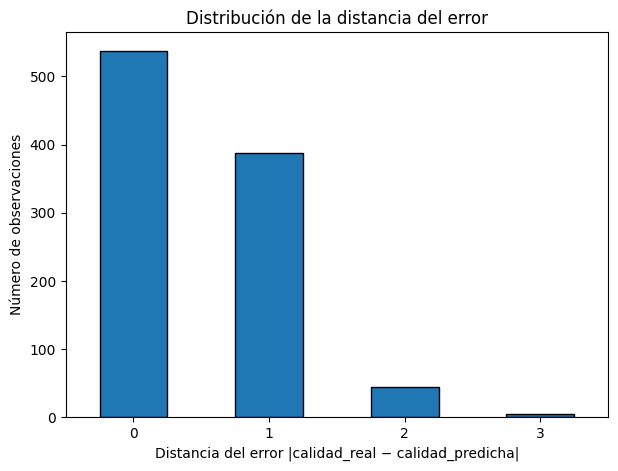

In [13]:
import matplotlib.pyplot as plt

# Histograma de la distancia del error
plt.figure(figsize=(7, 5))
error_df["distancia_error"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribución de la distancia del error")
plt.xlabel("Distancia del error |calidad_real − calidad_predicha|")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=0)
plt.show()

### Análisis de la distribución de la distancia del error

Esta gráfica muestra **cuánto se equivoca el modelo cuando se equivoca**.

La lectura es bastante clara:

* **La barra en 0** es la más alta:
  representa los casos donde el modelo **acierta exactamente** la calidad del vino. Esto coincide con el accuracy observado.

* **La mayoría de los errores tienen distancia 1**:
  es decir, cuando el modelo falla, **normalmente se equivoca por un solo nivel de calidad** (por ejemplo, predice 5 en lugar de 6).
  Estos son errores **leves y esperables** en un problema ordinal.

* **Los errores de distancia 2 son pocos**, y

* **los errores de distancia 3 son muy raros**.

Qué nos dice esto, en términos simples:

* El modelo **no comete errores extremos de forma sistemática**.
* No “confunde vinos malos con excelentes” ni viceversa.
* Sus fallos están **concentrados cerca del valor correcto**.

Conclusión clave:

> Aunque el modelo no es perfecto, **la forma en que se equivoca es razonable**.

Esto refuerza una idea central del notebook:

* el problema no es solo **cuántos errores hay**,
* sino **qué tipo de errores son**.

📌 Esta gráfica no justifica decisiones todavía,
📌 pero muestra que el modelo produce **errores mayoritariamente tolerables**, lo cual será crucial cuando hablemos de riesgo y umbrales más adelante.


---
---
---

## 4.4 El espejismo del “modelo bueno”

Hasta aquí, el modelo parece razonable:
- el accuracy es aceptable,
- la mayoría de los errores son pequeños,
- no hay comportamientos claramente caóticos.

Sin embargo, aquí aparece un punto crítico:

> **Un modelo puede verse “bueno” en métricas agregadas  
> y aun así ser peligroso en uso real.**

### Buen accuracy ≠ buen comportamiento operativo

El accuracy resume todo en un solo número.  
Pero ese número **no distingue**:

- errores frecuentes pero leves,
- errores raros pero graves,
- casos donde el modelo está muy seguro… y se equivoca.

Dos modelos pueden tener el mismo accuracy y:
- uno equivocarse siempre por ±1,
- otro acertar mucho… pero fallar de forma catastrófica en pocos casos.

Para una métrica global, ambos “empatan”.  
Para una operación real, **no son equivalentes**.

### Qué esconden las métricas agregadas

Las métricas como accuracy o incluso F1:
- promedian comportamientos muy distintos,
- diluyen el riesgo en el promedio,
- no dicen **dónde** ni **cómo** se falla.

En nuestro caso:
- el modelo concentra predicciones en valores centrales,
- tiende a “aplanar” las calidades extremas,
- y puede producir probabilidades relativamente altas incluso cuando se equivoca.

Nada de esto aparece reflejado en el accuracy.

### Conexión con el Notebook 3

En el Notebook 3 vimos que el modelo produce:
- distribuciones de probabilidad,
- scores internos,
- niveles de confianza variables.

Aquí se hace evidente el punto clave:

📌 **Las métricas evalúan resultados.  
📌 Las probabilidades revelan el riesgo.**

Un modelo “bueno” según métricas:
- no es todavía un modelo **usable para decidir**,
- solo es un generador de señales.

### Mensaje central de esta sección

- Las métricas no mienten,
- pero **tampoco cuentan toda la verdad**.

Antes de hablar de decisiones, umbrales o acciones:
- hay que mirar **dónde falla**,
- con **qué confianza falla**,
- y **qué costo tendría ese fallo**.

📌 Medir bien no evita errores.  
📌 Entender el error es lo que permite decidir.

---
---
---

## 4.5 Accuracy vs probabilidad: cuando acertar no basta

Hasta ahora hemos hablado de **aciertos y errores**.  
Pero aún falta una dimensión clave:

> **La confianza con la que el modelo acierta o falla.**

Dos situaciones muy distintas suelen mezclarse bajo el mismo accuracy:

- el modelo **acierta**, pero con **baja confianza**,
- el modelo **falla**, pero con **alta confianza**.

Desde el punto de vista de métricas:
- ambos casos cuentan como “1 acierto” o “1 error”.

Desde el punto de vista operativo:
- **no tienen el mismo riesgo**.



### Aciertos con baja confianza

Cuando el modelo acierta pero reparte la probabilidad entre varias clases:

- el acierto es frágil,
- pequeñas variaciones en los datos podrían cambiar la predicción,
- el modelo está diciendo implícitamente: *“no estoy seguro”*.

Estos casos:
- no son problemáticos,
- pero **no deberían activar decisiones automáticas fuertes**.



### Errores con alta confianza (el caso peligroso)

Cuando el modelo se equivoca **estando muy seguro**:

- asigna una probabilidad alta a una clase incorrecta,
- transmite una falsa sensación de certeza,
- oculta el riesgo bajo un “output limpio”.

Este es el escenario más delicado:
- el error no es solo técnico,
- es **operativamente engañoso**.

📌 Un error con alta confianza es más peligroso  
📌 que un error con duda explícita.



### Por qué el accuracy no ve esto

El accuracy:
- solo evalúa si la clase final coincide o no,
- **ignora completamente la probabilidad asociada**,
- trata igual:
  - un acierto con 0.99 de probabilidad,
  - un acierto con 0.35 de probabilidad.

Por eso:
- un modelo puede tener buen accuracy,
- y aun así producir **señales riesgosas**.



### Objetivo de esta sección

En los siguientes bloques vamos a:

- relacionar accuracy con **probabilidad máxima predicha**,
- identificar:
  - aciertos inseguros,
  - errores excesivamente confiados,
- mostrar, fila a fila, por qué **acertar no siempre basta**.

📌 Aquí seguimos sin decidir nada.  
📌 Solo exponemos dónde vive el riesgo.

### 4.5.1 Accuracy condicionada a la probabilidad máxima

En este bloque vamos a **cruzar el resultado del modelo con su nivel de confianza**.

La idea es simple:
- no mirar solo si el modelo acierta o falla,
- sino **con qué probabilidad máxima lo hace**.

Para ello:
- usaremos la **probabilidad máxima predicha** por fila,
- y la relacionaremos con:
  - aciertos,
  - errores.

Este análisis permite:
- detectar **aciertos inseguros** (correctos pero con baja probabilidad),
- identificar **errores peligrosos** (incorrectos con alta probabilidad),
- mostrar por qué el accuracy, por sí solo, **no refleja el riesgo real**.

📌 No se definen umbrales.  
📌 No se toman decisiones.  
📌 Solo se revela la relación entre **confianza y error**.

In [14]:
# 1) Probabilidad máxima (confianza) por observación
max_proba = y_proba.max(axis=1)

# 2) Indicador de acierto/error
is_correct = (y_pred == y_test)

# 3) Dataset de análisis (fila a fila)
conf_df = pd.DataFrame({
    "calidad_real": y_test,
    "calidad_predicha": y_pred,
    "max_proba": max_proba,
    "acierto": is_correct
})

conf_df.head()

,calidad_real,calidad_predicha,max_proba,acierto
0,6,5,0.609873,False
1,6,6,0.516179,True
2,5,5,0.541916,True
3,6,6,0.547347,True
4,7,6,0.551047,False


> Esta imagen muestra cómo el modelo compara la **calidad real del vino** (eje vertical) con la **calidad que el modelo predice** (eje horizontal).
>
> Los números sobre la diagonal indican los aciertos: cuando el modelo predijo exactamente la misma calidad que la real. Por ejemplo, se observa que muchos vinos con calidad **6** fueron correctamente identificados como **6**, lo que explica el bloque más oscuro en el centro.
>
> Fuera de la diagonal aparecen los errores. La mayoría de ellos ocurren entre valores cercanos, como confundir un **5 con un 6** o un **6 con un 7**. Esto es bastante natural, ya que incluso para una persona distinguir entre calidades muy parecidas no siempre es sencillo.
>
> Casi no se ven errores extremos, como decir que un vino de calidad baja es de calidad muy alta, o viceversa. Esto indica que el modelo no “se desorienta”, sino que se equivoca de forma moderada.
>
> En conjunto, la imagen muestra que el modelo entiende el orden general de las calidades y que, cuando falla, suele hacerlo por poco. Esto no significa que ya podamos tomar decisiones automáticas con él, pero sí que sus errores son coherentes y fáciles de interpretar.

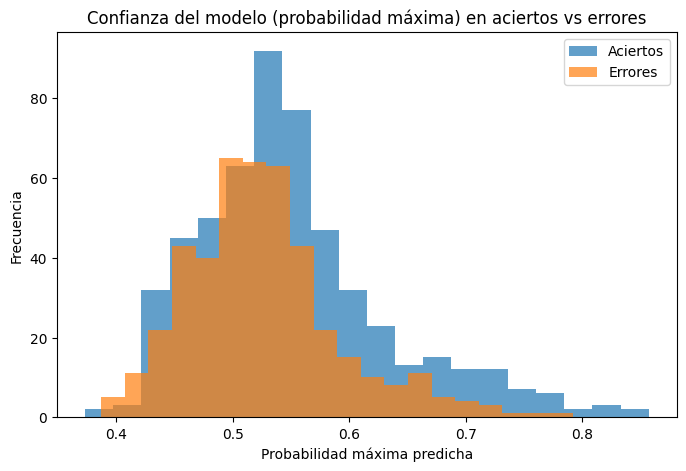

In [15]:
# Visualización: distribución de la confianza separada por acierto vs error
plt.figure(figsize=(8, 5))

plt.hist(conf_df.loc[conf_df["acierto"], "max_proba"], bins=20, alpha=0.7, label="Aciertos")
plt.hist(conf_df.loc[~conf_df["acierto"], "max_proba"], bins=20, alpha=0.7, label="Errores")

plt.title("Confianza del modelo (probabilidad máxima) en aciertos vs errores")
plt.xlabel("Probabilidad máxima predicha")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

> Esta gráfica compara la **confianza del modelo** (probabilidad máxima) cuando **acierta** frente a cuando **se equivoca**.
>
> Se observa que las distribuciones **se solapan fuertemente**: el modelo puede fallar con niveles de confianza muy similares a los que tiene cuando acierta.
>
> No existe una separación clara donde “alta probabilidad = acierto” y “baja probabilidad = error”. De hecho, aparecen **errores con probabilidades relativamente altas**, lo que confirma la presencia de **falsas certezas**.
>
> Esto demuestra que una probabilidad alta **no garantiza** una predicción correcta y que el modelo aún no está bien calibrado.
>
> En conjunto, la gráfica refuerza la idea central:
> **la confianza del modelo no puede usarse directamente para decidir**, y debe analizarse explícitamente antes de definir umbrales o acciones.

In [17]:
# Accuracy condicionada por rangos de confianza (binning)
bins = [0.0, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.01]
conf_df["bin_confianza"] = pd.cut(conf_df["max_proba"], bins=bins, right=False)

acc_by_bin = conf_df.groupby("bin_confianza")["acierto"].mean()
count_by_bin = conf_df["bin_confianza"].value_counts().sort_index()

acc_by_bin

bin_confianza
[0.3, 0.4)    0.600000
[0.4, 0.5)    0.463576
[0.5, 0.6)    0.556660
[0.6, 0.7)    0.646552
[0.7, 0.8)    0.790698
[0.8, 0.9)    1.000000
Name: acierto, dtype: float64

In [18]:
count_by_bin

bin_confianza
[0.0, 0.3)       0
[0.3, 0.4)       5
[0.4, 0.5)     302
[0.5, 0.6)     503
[0.6, 0.7)     116
[0.7, 0.8)      43
[0.8, 0.9)       6
[0.9, 1.01)      0
Name: count, dtype: int64

> Este código **agrupa las predicciones del modelo según su nivel de confianza** (probabilidad máxima predicha) y calcula, para cada rango, **qué porcentaje de aciertos hay** y **cuántos casos caen en ese rango**.
>
> La idea es simple: no mirar el accuracy como un único número, sino ver **qué tan confiable es el modelo cuando dice estar más o menos seguro**.
>
> Al analizar los resultados, se observa que en los rangos bajos y medios de confianza (0.4–0.6), donde se concentra la **mayoría de las predicciones**, el accuracy es **moderado e inestable**. Es decir, el modelo suele acertar apenas un poco más de la mitad de las veces, incluso cuando muestra cierta seguridad.
>
> A medida que la confianza aumenta, el accuracy mejora y llega a valores muy altos en los rangos superiores. Sin embargo, esos niveles de confianza extrema contienen **muy pocos ejemplos**, por lo que no representan el comportamiento típico del modelo.
>
> La lectura clave es clara: el modelo pasa la mayor parte del tiempo operando en una **zona de incertidumbre**, y los aciertos con alta confianza son escasos.
>
> 📌 Esto confirma que **la probabilidad predicha importa tanto como el acierto**, y que un buen accuracy global no implica que el modelo sea confiable para decidir en la mayoría de los casos.


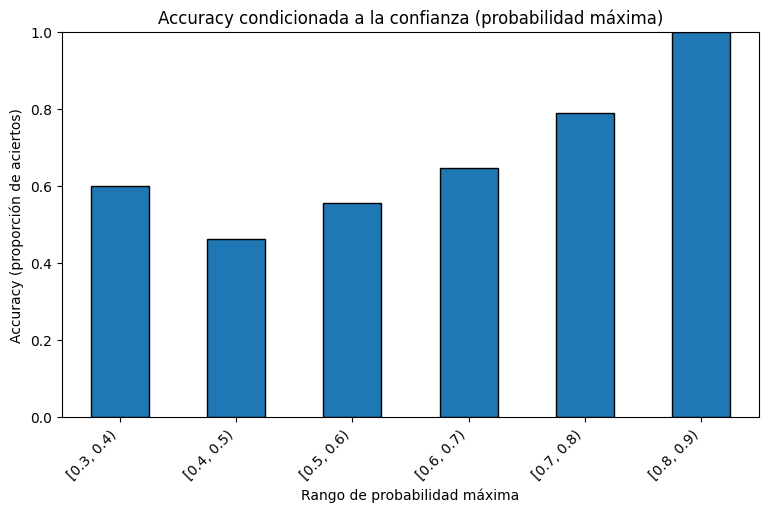

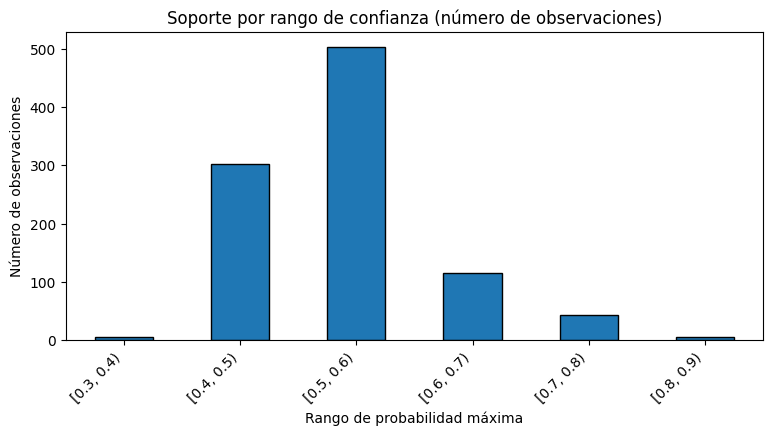

In [19]:
# Visualización: accuracy por bin de confianza (con soporte)
acc_by_bin = acc_by_bin.sort_index()
count_by_bin = count_by_bin.reindex(acc_by_bin.index)

plt.figure(figsize=(9, 5))
acc_by_bin.plot(kind="bar", edgecolor="black")
plt.title("Accuracy condicionada a la confianza (probabilidad máxima)")
plt.xlabel("Rango de probabilidad máxima")
plt.ylabel("Accuracy (proporción de aciertos)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(9, 4))
count_by_bin.plot(kind="bar", edgecolor="black")
plt.title("Soporte por rango de confianza (número de observaciones)")
plt.xlabel("Rango de probabilidad máxima")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=45, ha="right")
plt.show()

> **Qué hace este análisis**
> El código agrupa las predicciones del modelo según su **nivel de confianza** (probabilidad máxima) y calcula dos cosas por cada rango:
>
> 1. **qué tan seguido acierta** el modelo (accuracy condicionada),
> 2. **cuántos casos hay** en ese rango (soporte).
>    La idea es simple: no basta con saber si acierta, importa **con cuánta confianza** lo hace.

> **Lectura de los resultados**
> Se observa una relación clara: **a mayor confianza, mayor accuracy**.
>
> * En rangos bajos de probabilidad (≈ 0.4–0.5), el accuracy es bajo o inestable: el modelo duda y acierta poco.
> * En el rango medio (0.5–0.6), donde está la mayoría de los casos, el modelo acierta algo más, pero sigue siendo una zona gris.
> * En rangos altos (≥ 0.7), el accuracy sube fuerte: cuando el modelo está seguro, suele acertar.
>
> Al mismo tiempo, el gráfico de soporte muestra que **la mayoría de las predicciones viven en confianza media**, y **muy pocas en confianza alta**. Es decir: los aciertos “muy seguros” existen, pero son escasos.

> **Conclusión directa**
> El modelo **no es igual de confiable en todo su rango de salida**.
> Acertar con baja confianza no es tranquilizador, y fallar con alta confianza sería peligroso.
> Estas gráficas dejan claro por qué el accuracy global **esconde riesgo** y por qué la confianza debe entrar en juego antes de cualquier decisión.

In [20]:
# 4) Ejemplos fila a fila: (a) aciertos con baja confianza, (b) errores con alta confianza
low_conf_correct = conf_df[conf_df["acierto"]].sort_values("max_proba").head(10)
high_conf_wrong = conf_df[~conf_df["acierto"]].sort_values("max_proba", ascending=False).head(10)

low_conf_correct

,calidad_real,calidad_predicha,max_proba,acierto,bin_confianza
827,6,6,0.373136,True,"[0.3, 0.4)"
52,4,4,0.387185,True,"[0.3, 0.4)"
593,6,6,0.398375,True,"[0.3, 0.4)"
580,7,7,0.401780,True,"[0.4, 0.5)"
99,7,7,0.418935,True,"[0.4, 0.5)"
93,7,7,0.421668,True,"[0.4, 0.5)"
345,6,6,0.422232,True,"[0.4, 0.5)"
302,6,6,0.422362,True,"[0.4, 0.5)"
768,6,6,0.422839,True,"[0.4, 0.5)"
851,7,7,0.422984,True,"[0.4, 0.5)"


> **Qué muestra este resultado**
> Aquí se listan **aciertos del modelo con baja confianza**: casos donde la predicción fue correcta, pero la probabilidad máxima asignada es baja (≈ 0.37–0.42).

> **Lectura directa**
>
> * El modelo **acierta**, pero lo hace **con muchas dudas**.
> * La probabilidad está repartida entre varias clases cercanas, y la clase correcta apenas gana.
> * Son aciertos “frágiles”: un pequeño cambio en los datos podría convertirlos en errores.

> **Qué significa en la práctica**
>
> * Estos casos **no son peligrosos**, pero tampoco confiables para automatizar decisiones.
> * El modelo implícitamente está diciendo: *“acerté, pero no estaba seguro”*.

> **Mensaje clave**
> No todo acierto es un buen acierto.
> Estos ejemplos muestran por qué **acertar no basta** si no se considera la confianza.

In [21]:
high_conf_wrong

,calidad_real,calidad_predicha,max_proba,acierto,bin_confianza
611,3,5,0.792133,False,"[0.7, 0.8)"
503,7,5,0.768916,False,"[0.7, 0.8)"
947,4,5,0.739202,False,"[0.7, 0.8)"
523,6,5,0.728528,False,"[0.7, 0.8)"
884,4,5,0.719276,False,"[0.7, 0.8)"
536,4,5,0.717921,False,"[0.7, 0.8)"
377,6,7,0.709729,False,"[0.7, 0.8)"
144,6,5,0.705595,False,"[0.7, 0.8)"
14,6,5,0.700465,False,"[0.7, 0.8)"
419,4,5,0.694282,False,"[0.6, 0.7)"


### **4.6 Métricas ≠ políticas**

Las **métricas** sirven para **medir** el comportamiento de un modelo.
Las **políticas** sirven para **decidir qué hacer** con ese comportamiento.

Confundir ambas cosas es un error común.

* El accuracy, el log-loss o la matriz de confusión:

  * describen **qué tan bien funciona** el modelo,
  * **no dicen** cuándo usarlo, cuándo detenerlo o qué acción tomar.

* Una política necesita algo más:

  * tolerancia al error,
  * costo de equivocarse,
  * impacto operativo,
  * manejo explícito de incertidumbre.

Un mismo modelo puede ser:

* aceptable para **análisis exploratorio**,
* inaceptable para **decisiones automáticas**,
  aunque tenga las mismas métricas.

📌 **Las métricas informan.**
📌 **Las políticas gobiernan.**

Separarlas es lo que permite usar modelos de forma responsable.

### **4.7 Puente al siguiente notebook**

En este notebook quedó claro que:

* las métricas describen el desempeño,
* los errores no son todos iguales,
* y la **confianza del modelo** es tan importante como el acierto.

Sin embargo, todavía **no hemos tomado ninguna decisión**.

Lo que sigue pendiente es responder preguntas clave:

* ¿qué errores estamos dispuestos a aceptar?
* ¿cuáles son inaceptables?
* ¿cómo transformar probabilidades en acciones?

Eso es exactamente lo que abordaremos en el siguiente paso.

➡️ En el **Notebook 5 — *Precision, Recall and Thresholds***:

* analizaremos el **trade-off real entre tipos de error**,
* veremos cómo **mover el threshold** cambia el comportamiento del modelo,
* entenderemos por qué el threshold **no es tuning técnico**,
  sino una **política explícita de decisión**.

📌 Las métricas informan.
📌 El threshold decide.